In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import os
import sys
import random
from scipy.linalg import cho_solve, cho_factor

### In this tutorial, we will:

**Part 1**
1. Draw samples from GP prior   
2. Explore the regularization
3. Load a small dataset of **DFT-calculated C structures**.
4. Compute **SOAP descriptors** to represent atomic environments.
5. Write a simple **GAP** model ourselves.

**Part 2**

6. Train a CH **GAP** model via iterative training using melt-quench approach.
7. Evaluate how our CH **GAP** model improves over iterations.
   

### Requirements:
- `ase`
- `quippy`
- `matplotlib`
- `numpy`
- `gap_fit`


## Regularization

We will start by seeing how to draw samples from a GP prior, where 

$$
y \sim \mathcal{N}(0, K(X, X))
$$

So we will need to decide on a domain for $X$ and implement a kernel function $K$.
We will start using the radial basis function (RBF) kernel, 

$$
K(x, x^*) = \exp{\left(-\frac{|x-x^*|^2}{2\lambda^2}\right)}
$$
With $|x|$ being the euclidean distance of $x$. 
  $$
\mathrm{Var}(x) = K(x_*, x_*) + \sigma - K(x_*, x) (K(x,x) + \sigma^2 I)^{-1} K(x,x_*)
$$
**Log marginal likelihood** a measure of how well the Gaussian Process with given hyperparameters explains the observed data, balancing data fit and model complexity.

$$
\begin{equation}
\begin{aligned}
\mathrm{LML} = \log p(y | X ) =& -\frac{1}{2} \mathbf{y}^T(K(X, X) + \sigma^2_n I)^{-1}\mathbf{y} \\
& -\frac{1}{2} \log |K(X, X) + \sigma^2_n I| \\
& - \frac{n}{2} \log 2\pi
\end{aligned}
\end{equation}
$$
1. Data fit - how well do the function in the distribution fit the data?
2. Model complexity - how complex is the model? 
3. A normalization constant. 
In the cell below, implement the RBF kernel 


**Let's define a simple function and generate Training and Testing data** 

In [2]:
def f(x):
    return np.sin(2 * np.pi * x)
# Create noisy training data from a sine function
# Training data
n_train = 20
X_train = np.sort(np.random.uniform(-1.0, 1.0, size=n_train))[:, None]
y_train = f(X_train).ravel() + 0.15 * np.random.randn(n_train)

# Test date
X_test = np.linspace(-1.2, 1.2, 400)[:, None]
y_true = f(X_test).ravel()

In [3]:
#make an RBF kernel
def rbf_kernel(X1, X2, length_scale):
    d2 = cdist(X1, X2, metric="sqeuclidean")
    return np.exp(-0.5 * d2 / length_scale**2)

This is where the magic happens — we build a Gaussian Process (GP) model.

- Constructing covariance matrices between training and test points
- Solving the linear system using a Cholesky decomposition 
- Computing the posterior mean and covariance


$$
\mathrm{std}(X^*_i) = \sqrt{\sigma(X^*_i)}
$$

$$
\sigma(X^*_i) = \Sigma(X^*_i, X^*_i)
$$



The posterior covariance is given by

$$
\begin{equation}
\begin{aligned}
\Sigma(X^*, X^*) &= K_\mathrm{ss} - K_\mathrm{s} \cdot K^{-1} \cdot K_\mathrm{s}^T
\end{aligned}
\end{equation}
$$
where 
$$
K = K(X, X) + \sigma_n^2 I
$$
This allows us to assess both the fit to the data and the confidence of the model across the input space.


In [4]:
def gp_predict(X_train, y_train, X_test, length_scale=0.3, noise=1e-2):
    # Kernel matrices
    K = rbf_kernel(X_train, X_train, length_scale) + noise**2 * np.eye(len(X_train)) # training–training kernel
    Ks = rbf_kernel(X_test, X_train, length_scale) # test–training kernel (Ks)
    Kss = rbf_kernel(X_test, X_test, length_scale) # test–test kernel (Kss)

    # Cholesky solve
    L, lower = cho_factor(K, lower=True)
    alpha = cho_solve((L, lower), y_train)

    # Posterior mean
    mean = Ks @ alpha 

    # Posterior covariance
    v = cho_solve((L, lower), Ks.T)
    cov = Kss - Ks @ v
    var = np.clip(np.diag(cov), 0, None)

    return mean, var, cov, (L, lower, alpha)

**GP Prediction and Uncertainty Visualization**

We plot the posterior mean and uncertainty of the Gaussian Process.
 

In [5]:
def plot_gp(ax, X_train, y_train, X_test, y_true, length_scale, noise):
    mean, var, _, _ = gp_predict(
        X_train, y_train, X_test,
        length_scale=length_scale,
        noise=noise
    )

    std = np.sqrt(var)

    
    ax.plot(X_test, mean, label="GP mean")
    ax.fill_between(
        X_test.ravel(),
        mean - 2 * std,
        mean + 2 * std,
        alpha=0.25,
        label="var"
    )
    ax.scatter(X_train, y_train, color="red", zorder=3, label="Training data")
    ax.set_title(f"length={length_scale:.2f}, regularization={noise:.3f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

**Putting it all together**

We now have all the ingredients: the kernel, the data, and we can now construct the Gaussian Process model and examine its behavior.
The shaded region corresponds to ±2 standard deviations, representing model uncertainty. 

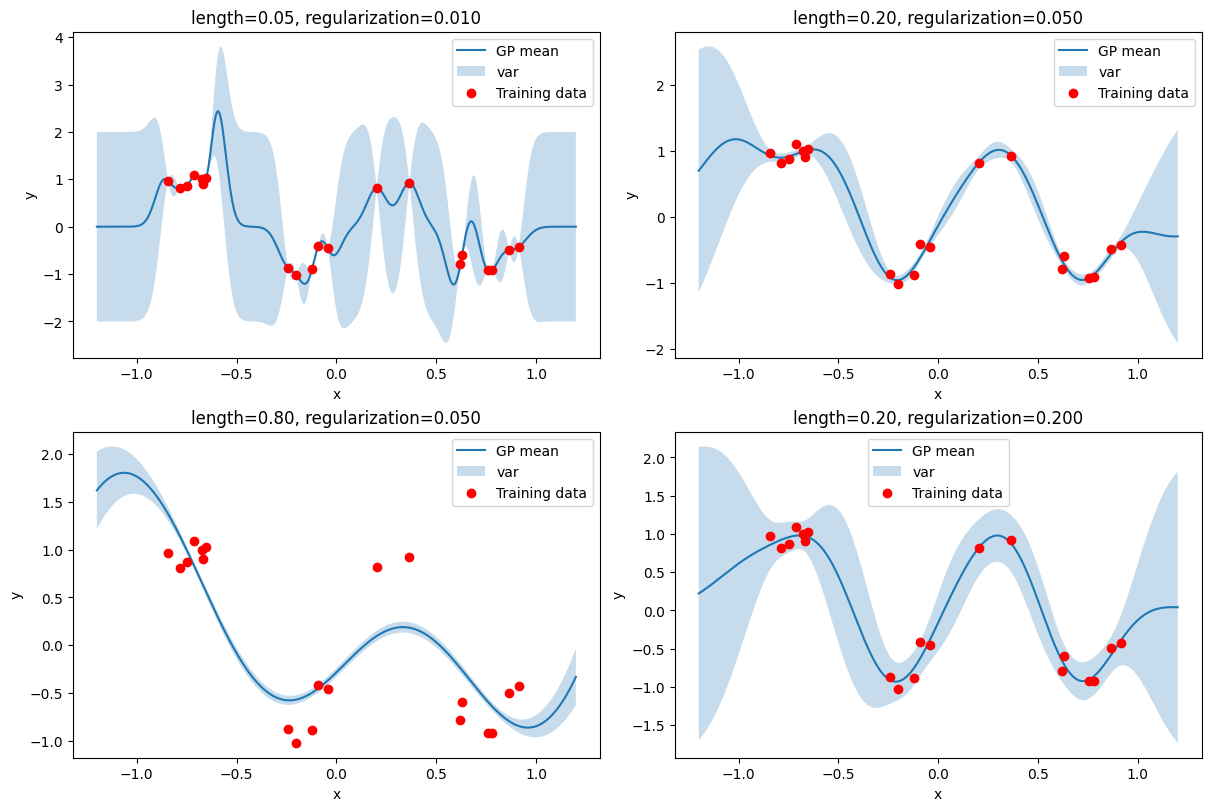

In [6]:
settings = [
    (0.05, 0.01),  # length and regularization/noise
    (0.20, 0.05),  
    (0.80, 0.05),   
    (0.20, 0.20),   
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for ax, (length_scale, noise) in zip(axes.ravel(), settings):
    plot_gp(ax, X_train, y_train, X_test, y_true, length_scale, noise)

plt.show()

### Influence of kernel hyperparameters

We examined the effect of kernel hyperparameters on the GP posterior.

- The **length** controls the correlation between input points, and how smooth is the function.
- The **noise level** is a regularization term, controls how closely we fit the data.


In [7]:
import ipywidgets as widgets
from ipywidgets import interact

@interact(length_scale=(0.03, 1.5, 0.02), noise=(0.005, 0.4, 0.005))
def interactive_gp(length_scale=0.2, noise=0.05):
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_gp(ax, X_train, y_train, X_test, y_true, length_scale, noise)
    ax.set_title(f"length={length_scale:.2f}, regularization={noise:.3f}")
    plt.show()

interactive(children=(FloatSlider(value=0.2, description='length_scale', max=1.5, min=0.03, step=0.02), FloatS…

<details>
    <summary><strong><span style="color: lightgreen; font-size: 18px;">💡 Try it later - Log marginal likelihood </span></strong></summary>
    <p> Uncomment the following function to calculate LML </p>
  </details>

In [33]:
# def log_marginal_likelihood(X_train, y_train, length_scale=0.3, noise=1e-2):
#     K = rbf_kernel(X_train, X_train, length_scale) + noise**2 * np.eye(len(X_train))
#     L, lower = cho_factor(K, lower=True)

#     alpha = cho_solve((L, lower), y_train)

#     lml = (
#         -0.5 * y_train @ alpha
#         - np.sum(np.log(np.diag(L)))
#         - 0.5 * len(X_train) * np.log(2 * np.pi)
#     )
#     return lml

<details>
    <summary><strong><span style="color: lightgreen; font-size: 18px;">💡 The marginal log likelihood lets us evaluate the model's ability to describe the data, allowing us to pick appropriate hyperparameters. </span></strong></summary>
    <p> Uncomment the following cells to calculate LML and select best hyperparameters </p>
  </details>

In [39]:
# length_scales = np.geomspace(0.03, 1.5, 60)
# noise_levels = np.geomspace(0.005, 0.4, 60)

# LML = np.zeros((len(noise_levels), len(length_scales)))

# for i, noise in enumerate(noise_levels):
#     for j, length_scale in enumerate(length_scales):
#         LML[i, j] = log_marginal_likelihood(
#             X_train, y_train,
#             length_scale=length_scale,
#             noise=noise
#         )

In [40]:
# best_idx = np.unravel_index(np.argmax(LML), LML.shape)
# best_noise = noise_levels[best_idx[0]]
# best_length = length_scales[best_idx[1]]

# fig, ax = plt.subplots(figsize=(7, 5))

# contour = ax.contourf(length_scales, noise_levels, LML, levels=30, cmap="viridis")
# ax.contour(length_scales, noise_levels, LML, levels=15, colors="white", linewidths=0.5)

# ax.plot(best_length, best_noise, "ro", markersize=8, label="Best LML")

# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.set_xlabel("Length scale")
# ax.set_ylabel("Noise / regularization")
# ax.set_title("Log marginal likelihood")
# ax.legend()

# fig.colorbar(contour, ax=ax, label="LML")
# plt.show()

# print(f"Best length scale = {best_length:.4f}")
# print(f"Best noise        = {best_noise:.4f}")

In [41]:
# fig, ax = plt.subplots(figsize=(8, 5))
# plot_gp(ax, X_train, y_train, X_test, y_true, best_length, best_noise)
# ax.set_title("Best model from log marginal likelihood")
# plt.show()

## GAP regularization

In this notebook, we build a Gaussian Process Regression (GPR) model to predict atomic energies from SOAP (Smooth Overlap of Atomic Positions) descriptors.
We assume a local energy model:


$$E = \sum_{i=1}^{N} E_i(\mathbf{p}_i)$$

Where:

- $E_i$ is the local energy of atom _i_,

- $\mathbf{p}_i$ is the SOAP vector of atom _i_
  
$$E_{\text{total}}^{\text{test}} = \sum_{i \in \text{test}} \sum_{j \in \text{train}} \alpha_j \cdot k(\mathbf{p}_i, \mathbf{p}_j)$$
   
- $k(\mathbf{p}_i, \mathbf{p}_j)$ is the SOAP kernel
- $\alpha_j$ is the coefficient from GPR training
$$
\alpha_{\mathrm{opt}} = \arg\min_{\alpha} \left( \|K\alpha - y\|^2 + \sigma^2 \|\alpha\|^2 \right)
$$

The fitting coefficients can be then obtained from matrix inversion:
$$
\alpha = (K + \sigma^2 I)^{-1} y
$$
- $\alpha$ is a weight vector (length = number of training data points)              
- $ K $ is a kernel matrix, with entries $ K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$

- $\sigma^2$ is a regularization parameter
- $I$ - Identity matrix (same shape as \( K \))                                
- $ y$ - vector of training targets (e.g., atomic energies)
  $$
\Sigma(x_*, x_*) = K(x_*, x_*) + \sigma - K(x_*, x) (K(x,x) + \sigma^2 I)^{-1} K(x,x_*)
$$

In [ ]:
#pip install quippy-ase

### Initialize SOAP descriptor using quippy

In [8]:
from weas_widget import WeasWidget
from quippy.descriptors import Descriptor 
from ase.io import read, write

In [9]:
# Descriptor string 
soap_str = "soap cutoff=3 l_max=4 n_max=4 atom_sigma=0.5 n_Z=1 Z1=6"




**Important parameters**:

*cutoff=3* - cutoff radius of 3 Å

*l_max=4* -  spherical harmonics are expanded up to angular momentum 4

*n_max=4* - the radial basis expansion uses 4 radial basis functions

*atom_sigma* - width of a Gaussian function, which controls how sharp is the kernel

In [10]:
# Initialize SOAP descriptor
soap_descriptor = Descriptor(soap_str)

### Prepare and visualize the structures
For this example let's load a fraction of carbon structures from [Deringer & Csányi, *Phys. Rev. B* **95**, 094203 (2017)](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.95.094203). 
The xyz file contains diamond and graphitic carbon structures.

In [11]:
atoms = read("bulk_cryst.xyz", index=":") # run with index="-1" so see the last snapshot only
viewer = WeasWidget()
viewer.avr.model_style = 1 # ball & stick mode
viewer.from_ase(atoms)
viewer.avr.show_bonded_atoms = True # show bonds across periodic boundaries
print("The database has:", len(atoms), " carbon structures")
viewer

The database has: 356  carbon structures


WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x7fb30fc13a10>,))

**For this example, we will build a "GAP-like" model.** 

Compute SOAP descriptors and Energy per atom

We have a total energy of the structure. However, in order to learn our fitting coefficients, we need a decomposition of energy. What if we simply assume that energy can be devided by the number of atoms in the structure?
We assign per-atom energies by dividing the total energy of the structure equally among its atoms (simple assumption). Then each atom gets a SOAP descriptor. 

In [52]:
# def build_atomic_dataset(structures, descriptor):
#     X_all = []
#     e_all = []

#     for atoms in structures:
#         E_total = atoms.get_potential_energy()

#         desc = descriptor.calc(atoms, descriptor_only=True)
#         X_atoms = desc["data"]

#         E_per_atom = E_total / len(atoms) # pay attention here, we are simply decomposing the total energy to the sum of energies per atom
#         e_atoms = np.full(len(atoms), E_per_atom)

#         X_all.append(X_atoms)
#         e_all.append(e_atoms)

#     X = np.vstack(X_all)
#     e = np.concatenate(e_all)

#     return X, e

In [53]:
# def train_gap_like_model(X_train, e_train, sigma_n=1e-2, zeta=4):
#     K = soap_kernel_matrix(X_train, X_train, zeta=zeta)
#     K += sigma_n**2 * np.eye(len(X_train))

#     L = np.linalg.cholesky(K)
#     y1 = np.linalg.solve(L, e_train)
#     alpha = np.linalg.solve(L.T, y1)

#     return alpha, K, L

In [12]:
from utils.descriptors import make_soap_descriptor, build_atomic_dataset
from utils.kernel import soap_kernel_matrix, train_gap_like_model
from utils.predict import predict_structure_energy, predict_dataset
from utils.helpers import split_xyz, parity_plot
from sklearn.metrics import r2_score, mean_squared_error



In [13]:
train_file, test_file = split_xyz("bulk_cryst.xyz", test_size=0.45, seed=42)

train_structures = read(train_file, ":")
test_structures = read(test_file, ":")

print(f"Train structures: {len(train_structures)}")
print(f"Test structures: {len(test_structures)}")

Loaded 356 structures from bulk_cryst.xyz
Split complete: 195 train, 161 test
Train structures: 195
Test structures: 161


X_train shape: (1196, 51)
e_train shape: (1196,)


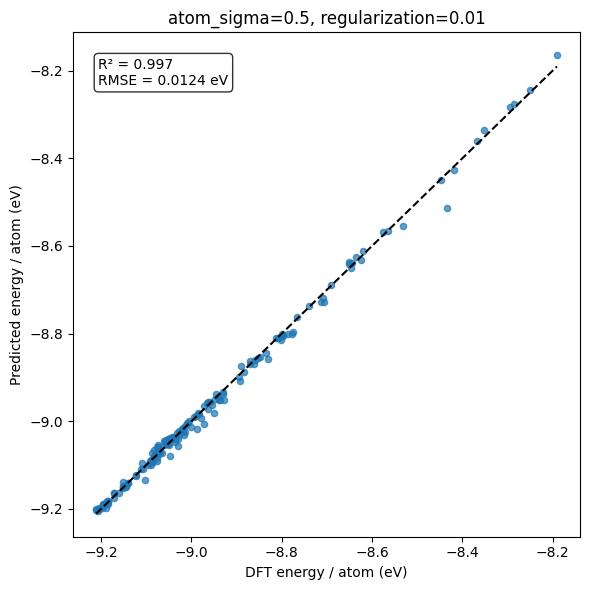

In [14]:
atom_sigma = 0.5 # hyperparameter
sigma_n = 1e-2 # hyperparameter
zeta = 4

soap_descriptor = make_soap_descriptor(atom_sigma=atom_sigma)
X_train, e_train = build_atomic_dataset(train_structures, soap_descriptor)

print("X_train shape:", X_train.shape)
print("e_train shape:", e_train.shape)

alpha, K, L = train_gap_like_model(X_train, e_train, sigma_n=sigma_n, zeta=zeta)

y_true, y_pred = predict_dataset(test_structures, soap_descriptor, X_train, alpha, zeta=zeta)
parity_plot(y_true, y_pred, title=f"atom_sigma={atom_sigma}, regularization={sigma_n}")

### Try your own hyperparameters
Choose four combinations of:

- `atom_sigma` = width of the Gaussian
- `sigma_n` = regularization

Then compare the parity plots!


In [ ]:
selected_settings = [
    (atom_sigma1, reg1),   # modify the cell and add your own atom_sigma and sigma_n parameters
    (atom_sigma2, reg2),   
    (atom_sigma3, reg3),   #Try very sharp width of the Gaussian
    (atom_sigma4, reg4),   # Try stronger regularization
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, (atom_sigma, sigma_n) in zip(axes.ravel(), selected_settings):
    descriptor = make_soap_descriptor(atom_sigma=atom_sigma)
    X_train, e_train = build_atomic_dataset(train_structures, descriptor)
    alpha, K, L = train_gap_like_model(X_train, e_train, sigma_n=sigma_n, zeta=4)
    y_true, y_pred = predict_dataset(test_structures, descriptor, X_train, alpha, zeta=4)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    ax.scatter(y_true, y_pred, s=12, alpha=0.7)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "k--")
    ax.set_title(f"atom_sigma={atom_sigma}, regularization={sigma_n}\nRMSE={rmse:.4f}")
    ax.set_xlabel("DFT energy / atom")
    ax.set_ylabel("Predicted energy / atom")

plt.tight_layout()
plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatLogSlider, FloatSlider, IntSlider
from sklearn.metrics import mean_squared_error, r2_score

_model_cache = {}

def run_gap_view(atom_sigma=0.5, sigma_n=1e-2, zeta=4):
    key = (atom_sigma, sigma_n)

    if key in _model_cache:
        y_true, y_pred = _model_cache[key]
    else:
        descriptor = make_soap_descriptor(atom_sigma=atom_sigma)
        X_train, e_train = build_atomic_dataset(train_structures, descriptor)
        alpha, K, L = train_gap_like_model(X_train, e_train, sigma_n=sigma_n, zeta=zeta)
        y_true, y_pred = predict_dataset(test_structures, descriptor, X_train, alpha, zeta=zeta)
        _model_cache[key] = (y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, s=12, alpha=0.7)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        "k--",
        linewidth=1
    )

    ax.set_title(
        f"atom_sigma={atom_sigma:.3f}, regularization={sigma_n:.1e}"
        f"RMSE={rmse:.4f}, R²={r2:.4f}"
    )
    ax.set_xlabel("DFT energy / atom")
    ax.set_ylabel("Predicted energy / atom")
    plt.tight_layout()
    plt.show()


interact(
    run_gap_view,
    atom_sigma=FloatSlider(
        value=0.5, min=0.05, max=1.5, step=0.05, description="atom_sigma"
    ),
    sigma_n=FloatLogSlider(
        value=1e-2, base=10, min=-5, max=0, step=0.1, description="sigma_n"
    ),
    
);

interactive(children=(FloatSlider(value=0.5, description='atom_sigma', max=1.5, min=0.05, step=0.05), FloatLog…

# Iterative training

### Iterative Training Workflow (GAP + TurboGAP)

This notebook demonstrates a simple **iteration-by-iteration workflow** for training a GAP model using TurboGAP.
For training we need reference data, but it is impossible for us to run this workflow interactively and compute reference data with DFT. Therefore, we will accept that our "ground truth" will be reference data calculated with general-purpose CH GAP trained earlier [Ibragimova et al., Chem. Mater. 37, 1094–1110 (2025)](https://pubs.acs.org/doi/10.1021/acs.chemmater.4c02905).


### Workflow
All the input data and scripts are located in iterative_training/ folder.

Each iteration consists of 4 steps:

1. **Prepare training data** - run submission_script/**run_prepare.sh**
   - Merge previous dataset with new configurations
   - Add regularizations

2. **Fit GAP model** - run submission_script/**run_fit.sh**
   - Run gap_fit
   - Convert the model into `.gap` model

3. **Run TurboGAP MD** - run submission_script/**run_md.sh**
   - Melt + quench
   - Generate new structures

4. **Run prediction** - run submission_script/**run_predict.sh**
   - Evaluate structures
   - Assign configuration types

All the helping functions and scripts are in inputs/ folder, and the calculated data in iterations/ folder. 


In [8]:
# To run the scripts open the terminal and follow the commands:
# Make sure the scripts are executable:  cd submission_scripts ; chmod +x run_prepare.sh run_fit.sh run_md.sh run_predict.sh ; cd ..
# Step 1 submit the preparation script via : ./submission_scripts/run_prepare.sh 2 # 2 is the number of iteration, we start with 2.
# Step 2 submit the training via : ./submission_scripts/run_fit.sh 2 # we are doing the iteration 2 now
# Step 3 submit MD melt-quench protocol : ./submission_scripts/run_md.sh 2 # We melt the structure at 5000K and then quench it to 300K 
# Step 4 submit reference energy prediction via : ./submission_scripts/run_predict.sh 2 # We recalculate the generated structures with our general-purpose CH GAP and make a labeled db for the next iteration  
# Voilà, we have our first GAP and ready to fit the next version of it!

In [15]:
atoms = read("iterative_training/iterations/iter_1/train.xyz", index="::4") # run with index="-1" so see the last snapshot only
viewer = WeasWidget()
viewer.avr.model_style = 1 # ball & stick mode
viewer.from_ase(atoms)
viewer.avr.show_bonded_atoms = True # show bonds across periodic boundaries
print("The database has:", len(atoms), " CH structures")
viewer

The database has: 176  CH structures


WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x7fb2fbe9d6d0>,))

In [ ]:
atoms = read("iterative_training/iterations/iter_2/turbogap/trajectory_out.xyz", index="::5") # run with index="-1" so see the last snapshot only
viewer = WeasWidget()
viewer.avr.model_style = 1 # ball & stick mode
viewer.from_ase(atoms)
viewer.avr.show_bonded_atoms = True # show bonds across periodic boundaries
print("The database has:", len(atoms), " CH structures")
viewer

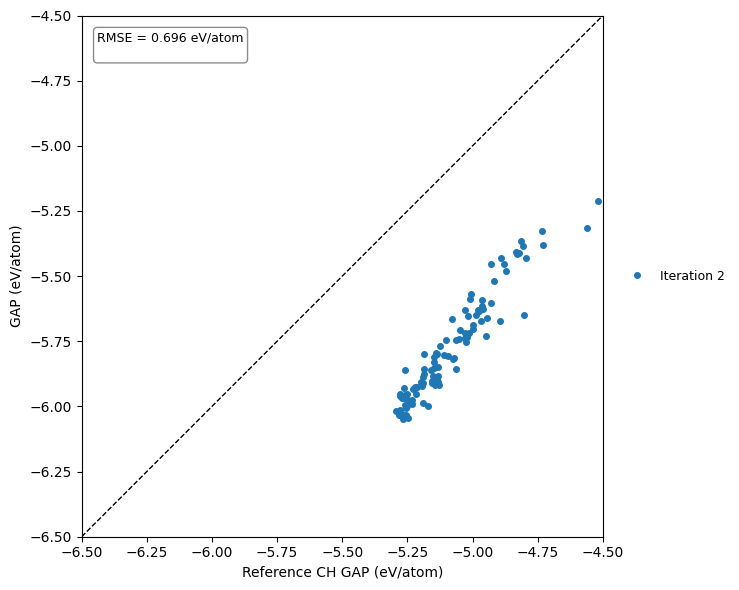

Written all_iterations.png


In [16]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

base = Path("iterative_training/iterations")

# Find all existing data files
files = sorted(
    base.glob("iter_*/ref/e_iter_*.dat"),
    key=lambda p: int(re.search(r"iter_(\d+)", str(p)).group(1))
)

if not files:
    raise FileNotFoundError(
        "No e_iter_*.dat files found in iterative_training/iterations/iter_*/ref/"
    )

fig, ax = plt.subplots(figsize=(8, 6))

all_ref = []
all_gap = []

for fname in files:
    match = re.search(r"iter_(\d+)", str(fname))
    iteration = int(match.group(1))

    data = np.loadtxt(fname, comments="#")
    if data.ndim == 1:
        data = data.reshape(1, -1)

    n = data[:, 0]
    e_ref = data[:, 1] / n
    e_gap = data[:, 2] / n

    all_ref.append(e_ref)
    all_gap.append(e_gap)

    ax.plot(e_ref, e_gap, "o", markersize=4, label=f"Iteration {iteration}")

# Concatenate all data for global metrics
all_ref = np.concatenate(all_ref)
all_gap = np.concatenate(all_gap)

# Metrics
residuals = all_gap - all_ref
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))

# Axis limits
xmin, xmax = -6.5, -4.5
ymin, ymax = -6.5, -4.5
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# x diagonal based on visible limits
line_min = max(xmin, ymin)
line_max = min(xmax, ymax)
ax.plot([line_min, line_max], [line_min, line_max], "--", color="black", linewidth=1)

# Labels
ax.set_xlabel("Reference CH GAP (eV/atom)")
ax.set_ylabel("GAP (eV/atom)")


ax.set_aspect("equal", adjustable="box")

# Metrics text box
metrics_text = (
    f"RMSE = {rmse:.3f} eV/atom\n"
)

ax.text(
    0.03, 0.97, metrics_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"),
    fontsize=9
)

# Legend outside
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

outname = "all_iterations.png"
fig.savefig(outname, dpi=150, bbox_inches="tight")
print(f"Written {outname}")

In [2]:
#Let's run the workflow in the loop by using a simple bash command:
# for numb in {3..10} ; do ./submission_scripts/run_prepare.sh ${numb} ; ./submission_scripts/run_fit.sh ${numb} ; ./submission_scripts/run_md.sh ${numb} ; ./submission_scripts/run_predict.sh ${numb} ; done
# While the workflow is runing let's have a closer look on what is behind the hood. 

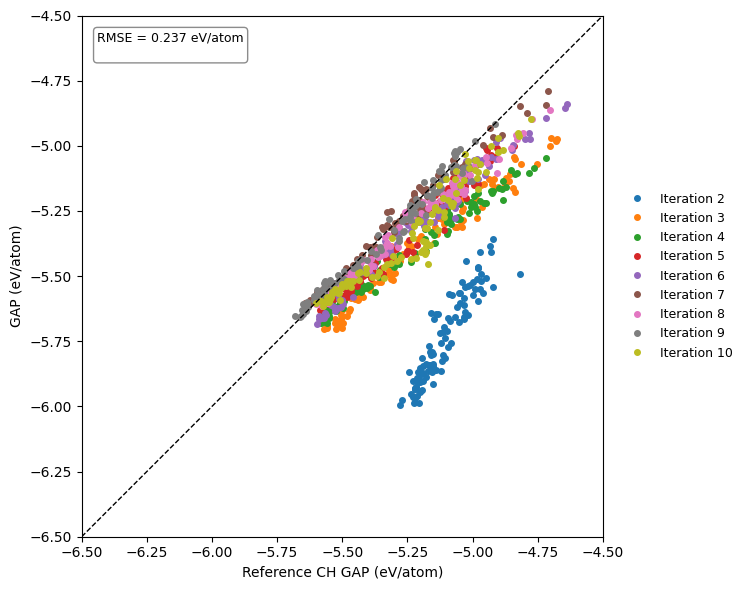

Written 10_iterations.png


In [23]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

base = Path("iterative_training/save/")

# Find all existing data files
files = sorted(
    base.glob("iter_*/ref/e_iter_*.dat"),
    key=lambda p: int(re.search(r"iter_(\d+)", str(p)).group(1))
)

if not files:
    raise FileNotFoundError(
        "No e_iter_*.dat files found in iterative_training/iterations/iter_*/ref/"
    )

fig, ax = plt.subplots(figsize=(8, 6))

all_ref = []
all_gap = []

for fname in files:
    match = re.search(r"iter_(\d+)", str(fname))
    iteration = int(match.group(1))

    data = np.loadtxt(fname, comments="#")
    if data.ndim == 1:
        data = data.reshape(1, -1)

    n = data[:, 0]
    e_ref = data[:, 1] / n
    e_gap = data[:, 2] / n

    all_ref.append(e_ref)
    all_gap.append(e_gap)

    ax.plot(e_ref, e_gap, "o", markersize=4, label=f"Iteration {iteration}")

# Concatenate all data for global metrics
all_ref = np.concatenate(all_ref)
all_gap = np.concatenate(all_gap)

# Metrics
residuals = all_gap - all_ref
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))

# Axis limits
xmin, xmax = -6.5, -4.5
ymin, ymax = -6.5, -4.5
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# x diagonal based on visible limits
line_min = max(xmin, ymin)
line_max = min(xmax, ymax)
ax.plot([line_min, line_max], [line_min, line_max], "--", color="black", linewidth=1)

# Labels
ax.set_xlabel("Reference CH GAP (eV/atom)")
ax.set_ylabel("GAP (eV/atom)")


ax.set_aspect("equal", adjustable="box")

# Metrics text box
metrics_text = (
    f"RMSE = {rmse:.3f} eV/atom\n"
)

ax.text(
    0.03, 0.97, metrics_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"),
    fontsize=9
)

# Legend outside
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

outname = "10_iterations.png"
fig.savefig(outname, dpi=150, bbox_inches="tight")
print(f"Written {outname}")

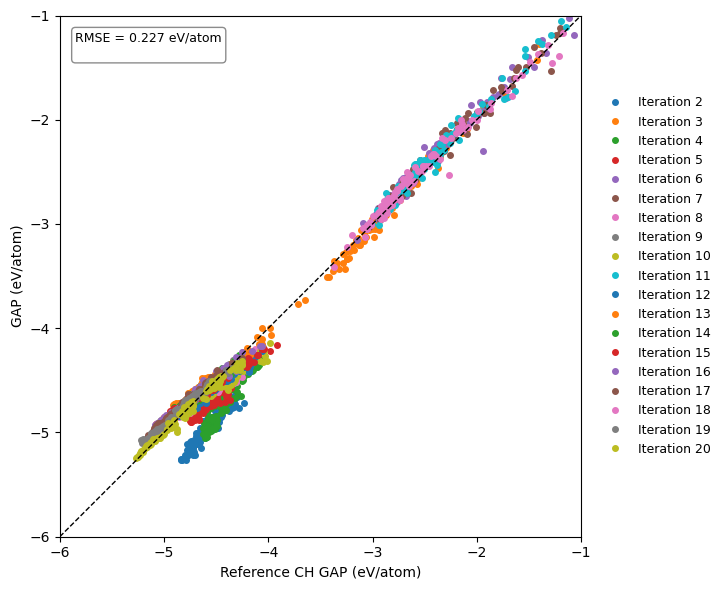

Written precomputed_iterations.png


In [21]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

base = Path("iterative_training/precalculated/")

# Find all existing data files
files = sorted(
    base.glob("iter_*/ref/e_iter_*.dat"),
    key=lambda p: int(re.search(r"iter_(\d+)", str(p)).group(1))
)

if not files:
    raise FileNotFoundError(
        "No e_iter_*.dat files found in iterative_training/iterations/iter_*/ref/"
    )

fig, ax = plt.subplots(figsize=(8, 6))

all_ref = []
all_gap = []

for fname in files:
    match = re.search(r"iter_(\d+)", str(fname))
    iteration = int(match.group(1))

    data = np.loadtxt(fname, comments="#")
    if data.ndim == 1:
        data = data.reshape(1, -1)

    n = data[:, 0]
    e_ref = data[:, 1] / n
    e_gap = data[:, 2] / n

    all_ref.append(e_ref)
    all_gap.append(e_gap)

    ax.plot(e_ref, e_gap, "o", markersize=4, label=f"Iteration {iteration}")

# Concatenate all data for global metrics
all_ref = np.concatenate(all_ref)
all_gap = np.concatenate(all_gap)

# Metrics
residuals = all_gap - all_ref
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))

# Axis limits
xmin, xmax = -6, -1
ymin, ymax = -6, -1
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# x diagonal based on visible limits
line_min = max(xmin, ymin)
line_max = min(xmax, ymax)
ax.plot([line_min, line_max], [line_min, line_max], "--", color="black", linewidth=1)

# Labels
ax.set_xlabel("Reference CH GAP (eV/atom)")
ax.set_ylabel("GAP (eV/atom)")


ax.set_aspect("equal", adjustable="box")

# Metrics text box
metrics_text = (
    f"RMSE = {rmse:.3f} eV/atom\n"
)

ax.text(
    0.03, 0.97, metrics_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"),
    fontsize=9
)

# Legend outside
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

outname = "precomputed_iterations.png"
fig.savefig(outname, dpi=150, bbox_inches="tight")
print(f"Written {outname}")

In [19]:
atoms = read("iterative_training/precalculated/iter_5/turbogap/trajectory_out.xyz", index="::5") # run with index="-1" so see the last snapshot only
viewer = WeasWidget()
viewer.avr.model_style = 1 # ball & stick mode
viewer.from_ase(atoms)
viewer.avr.show_bonded_atoms = True # show bonds across periodic boundaries
print("The database has:", len(atoms), " CH structures")
viewer

The database has: 21  CH structures


WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x7f0f37bbbc90>,))